<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/04_4_%EA%B5%AC%EA%B0%84_%EB%B6%84%ED%95%A0%2C_%EC%9D%B4%EC%82%B0%ED%99%94_%EA%B7%B8%EB%A6%AC%EA%B3%A0_%EC%84%A0%ED%98%95_%EB%AA%A8%EB%8D%B8%2C_%ED%8A%B8%EB%A6%AC_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules:
    if not os.path.isdir('mglearn'):
        # mglearn을 다운받고 압축을 풉니다.
        !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
        !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 데이터가 가진 의미, 어떤 모델을 사용하는지에 따라 데이터를 가장 잘 표현하는 방법은 달라짐

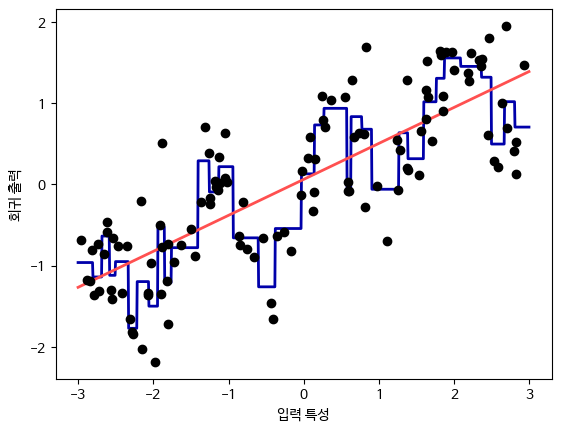

In [3]:
# wave 데이터셋에 적용한 선형 회귀와 결정 트리 비교
# wave 데이터셋: 입력 특성 한 개
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

X, y = mglearn.datasets.make_wave(n_samples=120)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

reg = DecisionTreeRegressor(min_samples_leaf=3).fit(X, y)
plt.plot(line, reg.predict(line), label="결정 트리")

reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="선형 회귀")

plt.plot(X[:, 0], y, "o", c="k")
plt.xlabel("입력 특성")
plt.ylabel("회귀 출력")
plt.show()

- **구간 분할**(bining)
  - 한 특성을 여러 특성을 나눔
  - 연속형 데이터에 아주 강력한 선형 모델을 만드는 방법
  - 데이터 포인트가 어떤 구간에 속하는지 나타낼 수 있음
  - 구간의 경계를 정의하는 방법
    - 균일한 너비 (구간의 경계 간의 거리가 동일)
    - 데이터 분위 사용 (데이터가 많은 구간은 좁아짐)  

In [4]:
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=10, strategy="uniform")
kb.fit(X)
print(f"bin edges:\n{kb.bin_edges_}")

bin edges:
[array([-2.967, -2.378, -1.789, -1.2  , -0.612, -0.023,  0.566,  1.155,
         1.744,  2.333,  2.921])                                       ]


- `transform` 메서드로 각 데이터 포인트에 해당되는 구간으로 인코딩 (기본적으로 구간에 원-핫-인코딩을 적용)
- 구간마다 하나의 새로운 특성이 생기므로 희소 행렬을 만듦
- 예에서 10개의 구간을 지정했기 때문에 변환된 데이터는 10차원

In [5]:
X_binned = kb.transform(X)
X_binned

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 120 stored elements and shape (120, 10)>

In [6]:
# 희소 행렬을 밀집 배열로 변환하여 원본 데이터 포인트와 인코딩 결과를 비교
print(X[:10])
X_binned.toarray()[:10]

[[-0.753]
 [ 2.704]
 [ 1.392]
 [ 0.592]
 [-2.064]
 [-2.064]
 [-2.651]
 [ 2.197]
 [ 0.607]
 [ 1.248]]


array([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])

In [7]:
# encode="onehot-dense": 원-핫-인코딩된 밀집 배열
kb = KBinsDiscretizer(n_bins=10, strategy="uniform", encode="onehot-dense")
kb.fit(X)
X_binned = kb.transform(X)

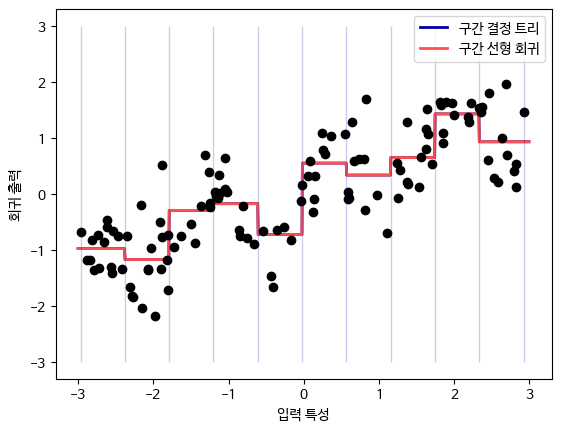

In [9]:
# 구간으로 나뉜 특성에 적용한 선형 회귀와 결정 트리 회귀의 비교

line_binned = kb.transform(line)

reg = DecisionTreeRegressor(min_samples_leaf=3).fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label="구간 결정 트리")

reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label="구간 선형 회귀")

plt.plot(X[:, 0], y, "o", c="k")
plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.xlabel("입력 특성")
plt.ylabel("회귀 출력")
plt.show()

- 선형 회귀모델과 결정 트리가 같은 예측을 만들어내 그래프가 겹침
- 각 구간 안에서는 특성의 값이 상수이므로, 어떤 모델이든 그 구간의 포인트에 대해서는 같은 값을 예측
- 선형 모델이 훨씬 유연해지고, 결정 트리는 덜 유연해짐 ➡️ 결정 트리는 데이터를 자유롭게 나눠 학습할 수 있으므로 구간 분할이 득이 되지 않음
- 일부 특성과 출력이 비선형 관계이지만, 용량이 매우 크고 고차원 데이터셋이라 선형 모델을 사용해야 한다면 구간 분할이 좋은 방법일 수 있음  